In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 335119


41
95


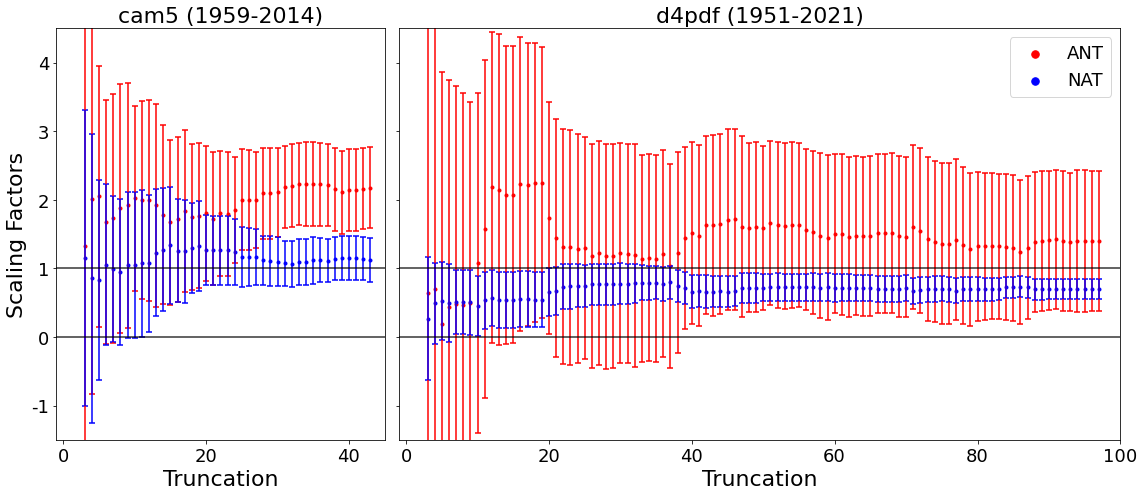

In [11]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

fig,axs = plt.subplots(1, 2, figsize=(16,7),gridspec_kw={'width_ratios': [1, 101/46]}, sharey=True)

axs = axs.flatten()

for i,model in enumerate(['cam5','d4pdf']):
    
    if model == 'cam5':
        start = '1959'
        end = '2014'
    elif model == 'd4pdf':
        start = '1951'
        end = '2021'
        
    plot_saved_result(model,axs[i],start,end,font)
    
axs[1].legend(fontsize=18,loc='upper right', markerscale=2.5)
axs[0].set_ylabel('Scaling Factors',fontdict=font)
axs[0].set_xlabel('Truncation',fontdict=font)
axs[1].set_xlabel('Truncation',fontdict=font)
axs[0].set_yticks([-1,0,1,2,3,4])
font['size'] = 18
axs[0].set_yticklabels(['-1','0','1','2','3','4'],fontdict=font)

#plt.subplots_adjust(wspace=0.05)
#plt.subplots_adjust(hspace=None)#, hspace=None)
plt.tight_layout()
plt.savefig('/home/queenle/fire_attribution/figures/Figure3_noise_doubled.png',dpi=300, transparent=False)


In [9]:
def plot_saved_result(model,ax,start_year,end_year,font):

    df = pd.read_csv('/home/queenle/fire_attribution/result_files/'+model+'_scan_beta_results_'+start_year+'_'+end_year+'NOISE_SCALED_2.csv')
    
    print(len(df['Truncation']))
    
    ax.scatter(df['Truncation'],df['ant_best'],color='red',marker='.',label='ANT')
    ax.scatter(df['Truncation'],df['ant_upper'],color='red',marker='_')
    ax.scatter(df['Truncation'],df['ant_lower'],color='red',marker='_')
    ax.vlines(df['Truncation'],df['ant_lower'],df['ant_upper'],color='red')

    ax.scatter(df['Truncation'],df['nat_best'],color='blue',marker='.',label='NAT')
    ax.scatter(df['Truncation'],df['nat_upper'],color='blue',marker='_')
    ax.scatter(df['Truncation'],df['nat_lower'],color='blue',marker='_')
    ax.vlines(df['Truncation'],df['nat_lower'],df['nat_upper'],color='blue')

    ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
    ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)
    ax.set_ylim(-1.5,4.5)
    
    font['size'] = 18
    if model == 'cam5':
        ax.set_xlim(-1,45)
        ax.set_xticks([20*i for i in range(3)])
        ax.set_xticklabels([str(20*i) for i in range(3)],fontdict=font)
    elif model == 'd4pdf':
        ax.set_xlim(-1,100)
        ax.set_xticks([20*i for i in range(6)])
        ax.set_xticklabels([str(20*i) for i in range(6)],fontdict=font)
    font['size'] = 22
    
    ax.set_title(model + ' ' + '(' + start_year + '-' + end_year + ')',fontdict=font)
    
    #plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/era5_fingerprinting/FWI/6month_fire_season/'+resample_interval+'/result.png')
    
    #plt.close(fig)
    

In [2]:
'''
Create vegetation land masks
'''
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

box = [(32,55),(232,256)]

In [8]:
'''
MAIN function for performing optimal fingerprinting using cam5 and ERA5
'''

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

vege_mask_flag = True

for i,model in enumerate(['cam5','d4pdf']):
    
    if model == 'cam5':
        continue
        
    if model == 'cam5':
        scen_dict = {'ALL':'All','NAT':'Nat'}
        range_dict = {'start':'1959','end':'2014'}
        vege_mask = cam5_vege_mask
    if model == 'd4pdf':
        scen_dict = {'ALL':'HPB','NAT':'HPB_NAT'}
        range_dict = {'start':'1951','end':'2021'}
        vege_mask = d4pdf_vege_mask
        
    IDL.retall

    print('getting ALL mean and noise')
    all_ens_mean,noise_all = get_mean_and_noise(model, scen_dict['ALL'], box, vege_mask_flag, range_dict['start'], range_dict['end'])
    print('getting NAT mean and noise')
    nat_ens_mean,noise_nat = get_mean_and_noise(model, scen_dict['NAT'], box, vege_mask_flag, range_dict['start'], range_dict['end'])

    print('getting obs')
    data_obs = get_obs_data(model, box, vege_mask, vege_mask_flag, range_dict['start'], range_dict['end'])
    print('got obs')
    data_scen = np.array([all_ens_mean,nat_ens_mean])

    if model == 'cam5':
        data_noise_1 = 2*np.concatenate((noise_all[:22],noise_nat[:24]))
        data_noise_2 = 2*np.concatenate((noise_all[22:],noise_nat[24:]))

    else:
        data_noise_1 = 2*np.concatenate((noise_all[:50],noise_nat[:50]))
        data_noise_2 = 2*np.concatenate((noise_all[50:],noise_nat[50:]))
        
    print('got arrays')

    if model == 'cam5':
        trunc = np.array([i for i in range(3,44)])
    if model == 'd4pdf':
        trunc = np.array([i for i in range(3,98)])
        
    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []
    
    '''
    print(data_obs.shape)
    print(data_scen.shape)
    print(data_noise_1.shape)
    print(data_noise_2.shape)
    print(trunc.shape)
    '''
    
    print('running gendetec')
    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid")

    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid

    #print(scan_beta_est)
    
    save_result(model,scan_beta_est,trunc,range_dict['start'], range_dict['end'])



getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


In [3]:
def get_obs_data(model, box, vege_mask, vege_mask_flag, start_year, end_year):
    
    if model == 'cam5':
        model_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
    else:
        model_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')

    if box != 'full':
        era5_da = era5_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        era5_da = era5_da.where(vege_mask>0)
        
    era5_da = era5_da.sel(time=slice(start_year,end_year))
    era5_da = era5_da.where(~model_da.isnull())
    
    era5_da = era5_da.stack(pixel=("latitude", "longitude"))
    era5_da = era5_da.dropna("pixel", how="all")        
    
    array = era5_da.values.flatten()
    
    #del era5_da
    
    return(array)


In [4]:
def get_noise(model,era5_da,scen,ens_mean,box,vege_mask_flag,start_year,end_year):
    
    if model == 'cam5':
        runs = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
                'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}
    else:
        runs = {'HPB':range(1,101),
                'HPB_NAT':range(1,101)}
    noise = []
    for ens_mem in runs[scen]:
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        if model == 'cam5':
            mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_run'+number+'.nc')
        elif model == 'd4pdf':
            mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_m'+number+'.nc')

        if box != 'full':
            mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        if vege_mask_flag:
            mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice(start_year,end_year))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
    return(noise)


In [5]:
def get_mean_and_noise(model, scen, box, vege_mask_flag, start_year, end_year):
    
    if model == 'cam5':
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
        ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_ensMean.nc')
    else:
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
        ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_ensMean.nc')
    
    if box != 'full':
        ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice(start_year,end_year))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = get_noise(model,era5_da,scen,ens_mean,box,vege_mask_flag,start_year,end_year)

    ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean.values.flatten()
    
    return((ens_mean_array, np.array(noise)))


In [6]:
def save_result(model,scan_beta_est,trunc,start,end):

    df_dict = {'Truncation':trunc,'ant_best':[],'ant_lower':[],'ant_upper':[],'nat_best':[],'nat_lower':[],'nat_upper':[]}
    
    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]
        #best_ant,low_ant,up_ant = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        #best_nat,low_nat,up_nat = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        df_dict['ant_best'].append(beta_est[0][0])
        df_dict['ant_lower'].append(beta_est[1][0])
        df_dict['ant_upper'].append(beta_est[2][0])
        
        df_dict['nat_best'].append(beta_est[0][1])
        df_dict['nat_lower'].append(beta_est[1][1])
        df_dict['nat_upper'].append(beta_est[2][1])
        
    df = pd.DataFrame.from_dict(df_dict)
    
    df.to_csv('fire_attribution/result_files/'+model+'_scan_beta_results_'+start+'_'+end+'NOISE_SCALED_2.csv')
    

In [ ]:
def plot_result(model,ax,scan_beta_est,scan_p_resid,start_year,end_year,font):

    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]
        best_ant,low_ant,up_ant = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_nat,low_nat,up_nat = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        ax.scatter([j+3]*3,[low_nat,best_nat,up_nat],c='blue',alpha=0.7,label='nat' if j == 0 else '')
        ax.scatter([j+3]*3,[low_ant,best_ant,up_ant],c='red',label='ant' if j == 0 else '')

        ax.vlines(j+3,low_nat,up_nat,colors=['blue'])
        ax.vlines(j+3,low_ant,up_ant,colors=['red'])

        ax.axhline(0,-0.5,1.5)
        ax.axhline(1,-0.5,1.5)
        
    ax.plot([i+3 for i in range(len(scan_p_resid))],scan_p_resid,c='black',label='p_resid')

    ax.legend(fontsize=14,loc='upper right')
    ax.set_ylim(-1,4.5)

    ax.set_title(model + ' ' + '(' + start_year + '-' + end_year + ')',fontdict=font)
    ax.tick_params(axis='x',labelsize=13)
    ax.tick_params(axis='y',labelsize=13)
    #plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/era5_fingerprinting/FWI/6month_fire_season/'+resample_interval+'/result.png')
    
    #plt.close(fig)
    